In [1]:
from datetime import datetime, timedelta

experiment = "abcEphys01"
probe_name = "ProbeB"
shank_id = 2
sorter_protocol = "lupin_TM"

start = datetime.strptime("2026-06-26 13:30:00", "%Y-%m-%d %H:%M:%S")
end = datetime.strptime("2026-06-27 12:00:00", "%Y-%m-%d %H:%M:%S")
# 2026 07 06 12:00
step = timedelta(minutes=30)

start_end_times = []
current = start
while current < end:
    next_time = min(current + step, end)
    start_end_times.append([current.strftime("%Y-%m-%d %H:%M:%S"), next_time.strftime("%Y-%m-%d %H:%M:%S")])
    current += step

In [ ]:
templates = []
for start, end in start_end_times:
    analyzer_path = Path(f'/run/user/1001/gvfs/smb-share:server=ceph-gw02.hpc.swc.ucl.ac.uk,share=scratch/chalcrow/fromgit/aeon_ss_playground/lupin_TM_si_output/{start.replace(" ", "T").replace(":", "-")}_{end.replace(" ", "T").replace(":", "-")}/shank_2/analyzer')
    analyzer = si.load_sorting_analyzer(analyzer_path, lazy=True)
    unit_index = analyzer.sorting.ids_to_indices([216])[0]
    channel_index=59
    extremal_template = analyzer.get_extension('templates').get_data()[unit_index,:,channel_index]
    templates.append(extremal_template)

    

In [45]:
import spikeinterface.full as si
from pathlib import Path


# Shape: (time index, sample , channel ) -> 6 functions, each having 100 frames of 500 points
templates = []
for start, end in start_end_times:
    analyzer_path = Path(f'/run/user/1001/gvfs/smb-share:server=ceph-gw02.hpc.swc.ucl.ac.uk,share=scratch/chalcrow/fromgit/aeon_ss_playground/lupin_TM_si_output/{start.replace(" ", "T").replace(":", "-")}_{end.replace(" ", "T").replace(":", "-")}/shank_2/analyzer')
    analyzer = si.load_sorting_analyzer(analyzer_path, lazy=True)
    unit_index = analyzer.sorting.ids_to_indices([216])[0]
    channel_indicies = analyzer.channel_ids_to_indices([256,257,254,255,252,253])
    extremal_template = analyzer.get_extension('templates').get_data()[unit_index,:,channel_indicies]
    templates.append(extremal_template)


In [53]:
firing_rates = []
for start, end in start_end_times:
    analyzer_path = Path(f'/run/user/1001/gvfs/smb-share:server=ceph-gw02.hpc.swc.ucl.ac.uk,share=scratch/chalcrow/fromgit/aeon_ss_playground/lupin_TM_si_output/{start.replace(" ", "T").replace(":", "-")}_{end.replace(" ", "T").replace(":", "-")}/shank_2/analyzer')
    analyzer = si.load_sorting_analyzer(analyzer_path, lazy=True)
    firing_rate = analyzer.get_extension('quality_metrics').get_data()['firing_rate'][216]
    firing_rates.append(firing_rate)

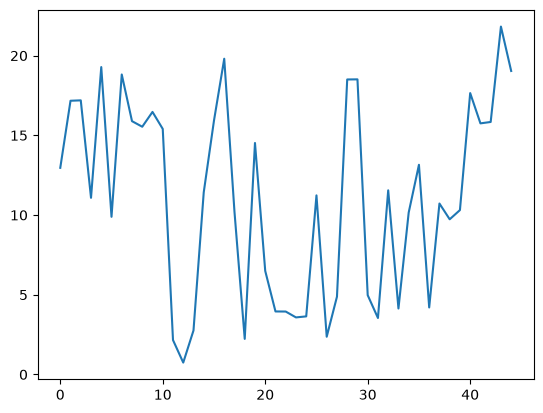

In [56]:
plt.plot(np.array(firing_rates))

In [57]:
np.argmin(np.array(firing_rates))

np.int64(12)

In [58]:
start_end_times[12]

['2026-06-26 19:30:00', '2026-06-26 20:00:00']

In [33]:
times = []
for start, end in start_end_times:
    times.append(start)

array([89])

In [22]:
analyzer

SortingAnalyzer: 92 channels - 153 units - 1 segments - binary_folder (lazy) - sparse
Loaded 1 extensions: templates

In [19]:
analyzer.main_channel_indices[89]

/home/chris/fromgit/aeon_ss_playground/.venv/lib/python3.13/site-packages/spikeinterface/core/sortinganalyzer.py:829: UserWarning: This sorting analyzer is from an an older version of spikeinterface (<0.105.0). For future compatibility we will compute the `main_channel_indices`. To keep this information on disk, please save your analyzer using `analyzer.save_as()`.
  warnings.warn(


np.int64(59)

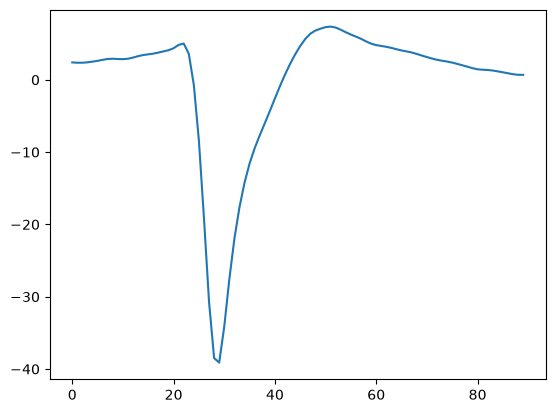

In [ ]:
import matplotlib.pyplot as plt
plt.plot(extremal_template)

In [37]:
templates[0]

array([[  2.40140963,   2.35582709,   2.35771608,   2.41155648,
          2.50619745,   2.62058163,   2.75814462,   2.87571168,
          2.90861011,   2.86975074,   2.84842229,   2.91018152,
          3.06906438,   3.26511884,   3.41978383,   3.51640224,
          3.61620665,   3.75999737,   3.92417121,   4.08970404,
          4.36246157,   4.8236475 ,   5.00672913,   3.59444141,
         -0.75156248,  -8.46592617, -19.19611168, -30.74060631,
        -38.48698807, -39.11095428, -34.12591934, -27.59791374,
        -21.9795723 , -17.63275146, -14.24098969, -11.57198906,
         -9.47168827,  -7.69047356,  -6.01678085,  -4.31711817,
         -2.57892561,  -0.8701365 ,   0.73239112,   2.2015655 ,
          3.51658511,   4.67222881,   5.65034294,   6.37775803,
          6.80833626,   7.06835032,   7.27650928,   7.35407639,
          7.22001076,   6.91917801,   6.56771946,   6.24881411,
          5.96533298,   5.66162252,   5.30571413,   4.98579121,
          4.79335022,   4.67366838,   4.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# 2. Setup static figure and axes
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_ylim(-50, 20)
ax.grid(True, linestyle="--", alpha=0.6)

# Initialize a line artist
(line,) = ax.plot(templates[0], lw=2)

title_text = ax.text(
    0.5, 1.03, "",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)

# 3. Fast update function (only updates data, no redraw of axes/labels)
def update(frame_idx):
    line.set_ydata(templates[frame_idx])
    title_text.set_text(f"{times[frame_idx]}")
    return (line,)

# 4. Build and save animation
anim = FuncAnimation(fig, update, frames=len(templates), blit=True)

# 20 fps means 100 frames takes 5 seconds
writer = PillowWriter(fps=20)
anim.save("functions_animation.gif", writer=writer)
plt.close(fig)

IndexError: list index out of range

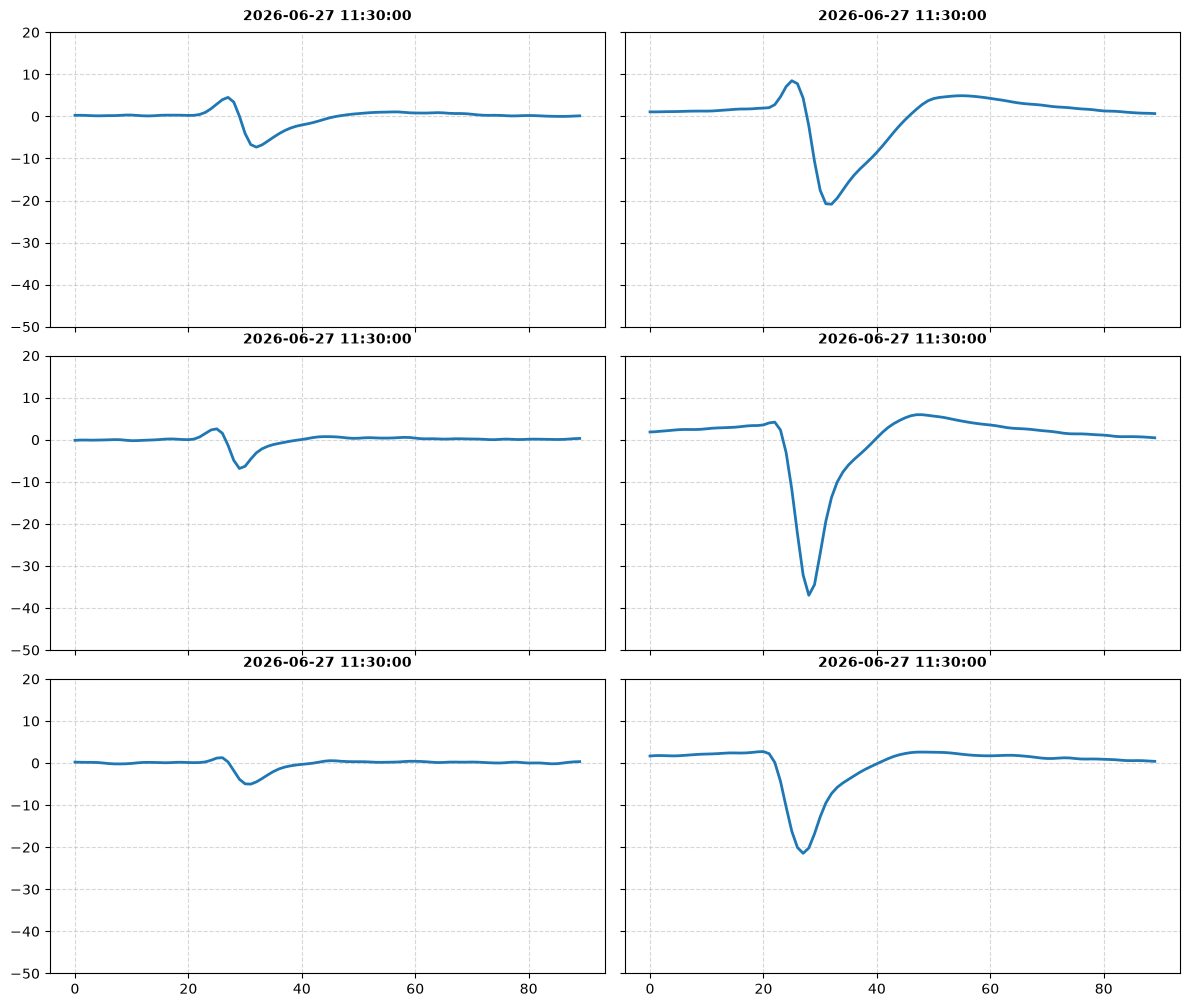

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# 1. Setup sample data: 100 frames for each of the 6 functions
num_functions = 6
num_frames = 100

# 2. Setup 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()  # Flatten to 1D array for easy iteration

lines = []
subplot_titles = []

for k, ax in enumerate(axes_flat):
    ax.set_ylim(-50, 20)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Line artist for each subplot
    (line,) = ax.plot(templates[0][0,:], lw=2)
    lines.append(line)

    # Per-subplot title
    title = ax.text(
        0.5, 1.03, "",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
    subplot_titles.append(title)

fig.tight_layout()

# 3. Update function returning all lines and titles
def update(frame_idx):
    updated_artists = []
    for k in range(num_functions):
        lines[k].set_ydata(templates[frame_idx][k,:])
        subplot_titles[k].set_text(f"{times[frame_idx]}")
        updated_artists.extend([lines[k], subplot_titles[k]])
    return updated_artists

# 4. Save animation
anim = FuncAnimation(fig, update, frames=num_frames, blit=True)
writer = PillowWriter(fps=20)
anim.save("grid_functions_animation.gif", writer=writer)
plt.close(fig)